In [412]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [413]:
#Load Dataset
df = pd.read_csv("Toronto Island Ferry Tickets.csv")

In [414]:
#Display first 5 row 
df.head()

,_id,Timestamp,Redemption Count,Sales Count
0,1,2025-12-21T22:30:00,14,16
1,2,2025-12-21T22:15:00,1,0
2,3,2025-12-21T22:00:00,2,0
3,4,2025-12-21T21:30:00,11,1
4,5,2025-12-21T21:15:00,10,0


In [415]:
#Display last 5 rows
df.tail()

,_id,Timestamp,Redemption Count,Sales Count
261533,261534,2015-05-04T16:00:00,0,2
261534,261535,2015-05-01T16:00:00,1,0
261535,261536,2015-05-01T15:45:00,0,1
261536,261537,2015-05-01T15:15:00,0,2
261537,261538,2015-05-01T13:30:00,0,1


In [416]:
#Check dataset shape
df.shape

(261538, 4)

In [417]:
#Column Names
df.columns

Index(['_id', 'Timestamp', 'Redemption Count', 'Sales Count'], dtype='str')

In [418]:
#Dataset Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 261538 entries, 0 to 261537
Data columns (total 4 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   _id               261538 non-null  int64
 1   Timestamp         261538 non-null  str  
 2   Redemption Count  261538 non-null  int64
 3   Sales Count       261538 non-null  int64
dtypes: int64(3), str(1)
memory usage: 8.0 MB


In [419]:
#Statistical Summary
df.describe()

,_id,Redemption Count,Sales Count
count,261538.000000,261538.000000,261538.000000
mean,130769.500000,48.885030,49.599106
std,75499.661689,104.549336,99.862285
min,1.000000,0.000000,0.000000
25%,65385.250000,3.000000,3.000000
50%,130769.500000,11.000000,13.000000
75%,196153.750000,40.000000,48.000000
max,261538.000000,7216.000000,7229.000000


In [420]:
#Check missing values
df.isnull().sum()

_id                 0
Timestamp           0
Redemption Count    0
Sales Count         0
dtype: int64

In [421]:
#Check duplicate values
df.duplicated().sum()

np.int64(0)

In [422]:
#Convert Timestamp to datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

In [423]:
#Verify datatype
df.dtypes

_id                          int64
Timestamp           datetime64[us]
Redemption Count             int64
Sales Count                  int64
dtype: object

In [424]:
#Create Time features
df["Year"] = df["Timestamp"].dt.year
df["Month"] = df["Timestamp"].dt.month
df["Month_Name"] = df["Timestamp"].dt.month_name()
df["Day"] = df["Timestamp"].dt.day
df["Hour"] = df["Timestamp"].dt.hour
df["Minute"] = df["Timestamp"].dt.minute
df["Weekday"] = df["Timestamp"].dt.day_name()

In [425]:
#Weekend Indicator
df["Is_Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"])

In [426]:
#Season Features
def season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

df["Season"] = df["Month"].apply(season)

In [427]:
#Totally Activity Load
df["Total Activity Load"] = df["Sales Count"] + df["Redemption Count"]

In [428]:
#Redemption Pressure Ratio
df["Redemption Pressure Ratio"] = df["Redemption Count"] / (df["Sales Count"] + 1)

In [429]:
#Operational Load Index(OLI)
df["Operational Load Index"] = (
    (df["Total Activity Load"] - df["Total Activity Load"].min()) /
    (df["Total Activity Load"].max() - df["Total Activity Load"].min())
)

In [430]:
#Idle Capacity indicator
threshold = df["Total Activity Load"].quantile(0.25)

df["Idle Capacity"] = df["Total Activity Load"] < threshold

In [431]:
#Save Cleared Dataset
df.to_csv("Toronto Island Ferry Tickets_Cleared.csv", index=False)

In [432]:
#Duplicate Records
duplicate_records = df[df.duplicated(keep=False)]

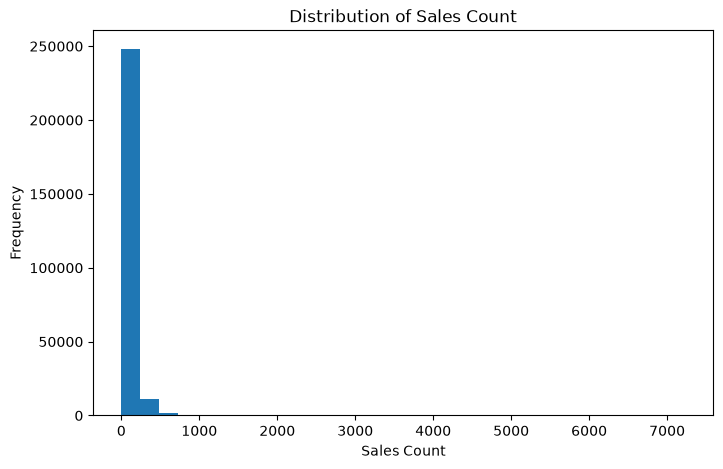

In [433]:
#Distribution of Sales count
plt.figure(figsize=(8,5))
plt.hist(df["Sales Count"], bins=30)
plt.title("Distribution of Sales Count")
plt.xlabel("Sales Count")
plt.ylabel("Frequency")
plt.show()

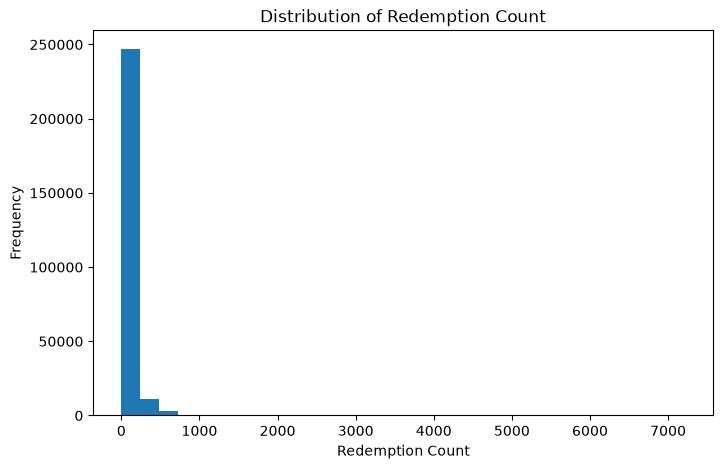

In [434]:
#dISTRIBUTION OF REDEMPTION COUNT
plt.figure(figsize=(8,5))
plt.hist(df["Redemption Count"], bins=30)
plt.title("Distribution of Redemption Count")
plt.xlabel("Redemption Count")
plt.ylabel("Frequency")
plt.show()

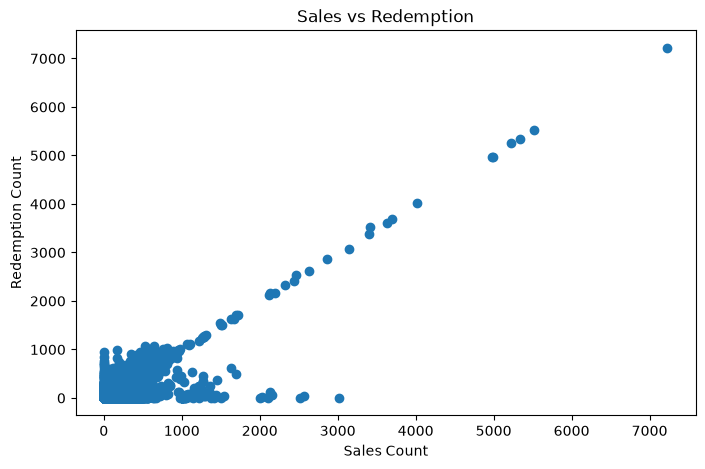

In [435]:
#Sales vs Redemption Count
plt.figure(figsize=(8,5))
plt.scatter(df["Sales Count"], df["Redemption Count"])
plt.title("Sales vs Redemption")
plt.xlabel("Sales Count")
plt.ylabel("Redemption Count")
plt.show()

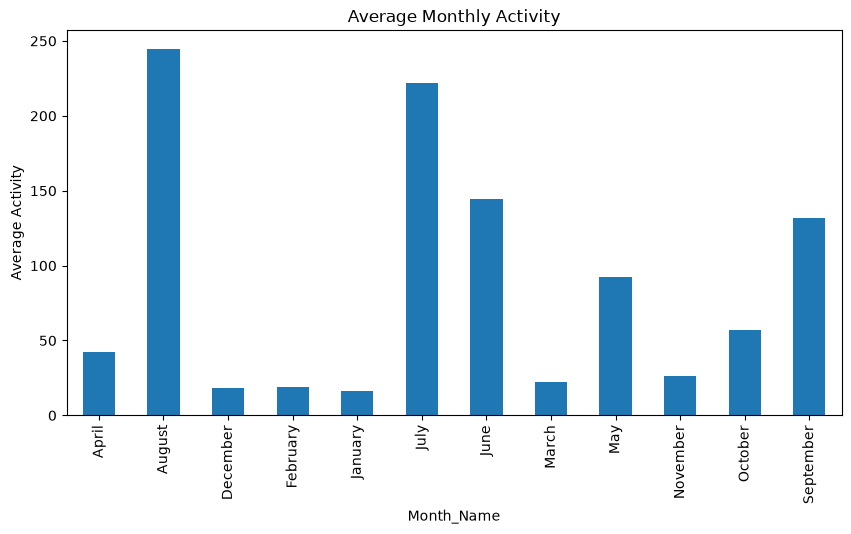

In [436]:
#Monthly Acticity 
monthly = df.groupby("Month_Name")["Total Activity Load"].mean()

monthly.plot(kind="bar", figsize=(10,5))
plt.title("Average Monthly Activity")
plt.ylabel("Average Activity")
plt.show()


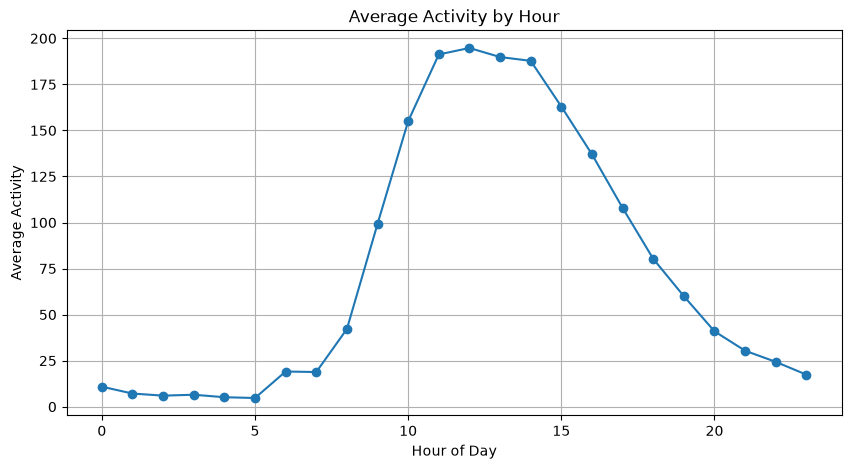

In [437]:
#Hourly Average Activity
hourly = df.groupby("Hour")["Total Activity Load"].mean()

plt.figure(figsize=(10,5))
plt.plot(hourly.index, hourly.values, marker='o')
plt.title("Average Activity by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Activity")
plt.grid(True)
plt.show()

In [438]:
df["Weekday"] = df["Timestamp"].dt.day_name()

In [439]:
df["Weekend"] = df["Weekday"].isin(["Saturday", "Sunday"])

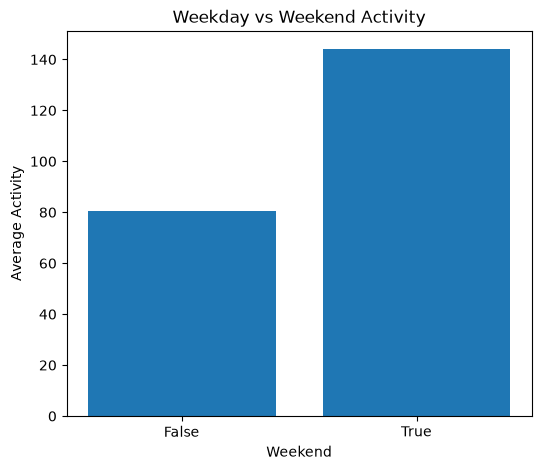

In [440]:
#Weekday vs Weekend
weekend = df.groupby("Weekend")["Total Activity Load"].mean()

plt.figure(figsize=(6,5))
plt.bar(weekend.index.astype(str), weekend.values)
plt.title("Weekday vs Weekend Activity")
plt.xlabel("Weekend")
plt.ylabel("Average Activity")
plt.show()

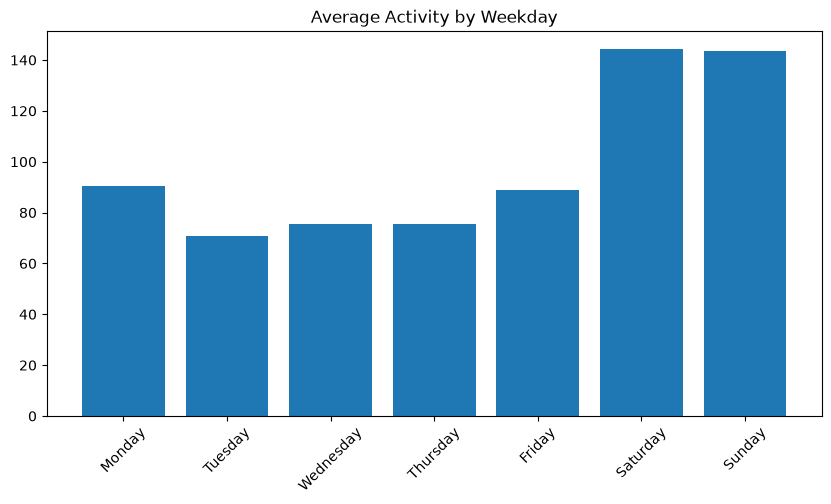

In [441]:
#Activity by Weekday
weekday = df.groupby("Weekday")["Total Activity Load"].mean()

weekday = weekday.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

plt.figure(figsize=(10,5))
plt.bar(weekday.index, weekday.values)
plt.xticks(rotation=45)
plt.title("Average Activity by Weekday")
plt.show()

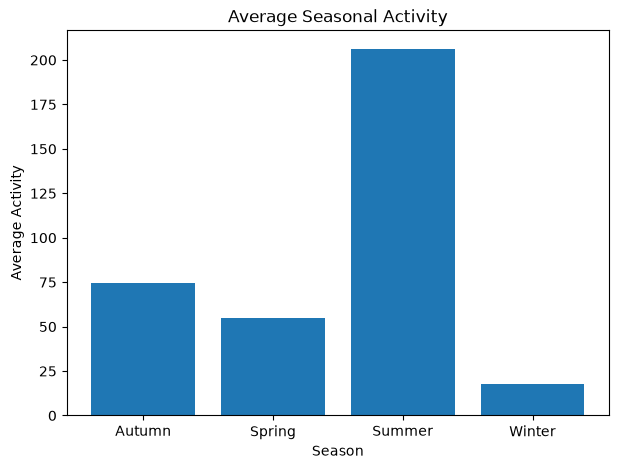

In [442]:
#Seasonal Activity
season = df.groupby("Season")["Total Activity Load"].mean()

plt.figure(figsize=(7,5))
plt.bar(season.index, season.values)
plt.title("Average Seasonal Activity")
plt.xlabel("Season")
plt.ylabel("Average Activity")
plt.show()

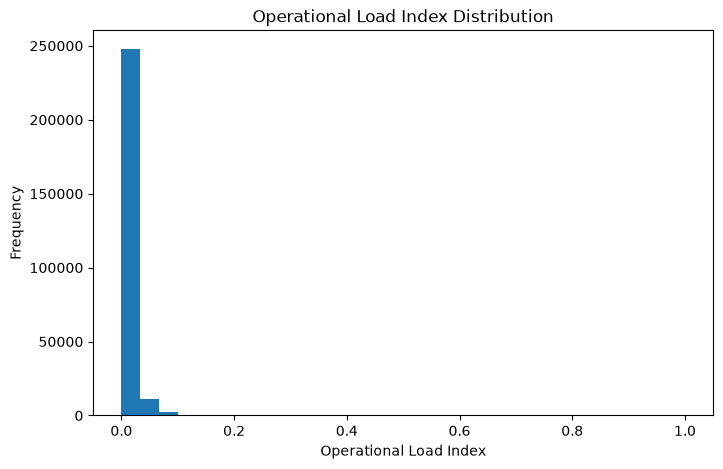

In [443]:
#Operational Load INDEX Distribution 
plt.figure(figsize=(8,5))
plt.hist(df["Operational Load Index"], bins=30)
plt.title("Operational Load Index Distribution")
plt.xlabel("Operational Load Index")
plt.ylabel("Frequency")
plt.show()

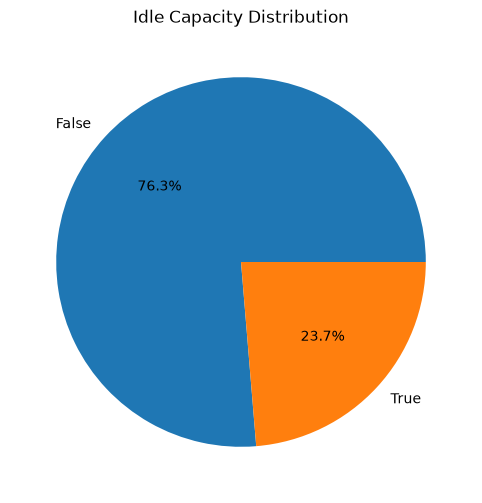

In [444]:
#Idle CAPACITY Distribution
idle = df["Idle Capacity"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(idle.values,
        labels=idle.index,
        autopct="%1.1f%%")
plt.title("Idle Capacity Distribution")
plt.show()

In [445]:
#correlation Analysis
corr = df[[
    "Sales Count",
    "Redemption Count",
    "Total Activity Load",
    "Operational Load Index"
]].corr()

print(corr)

                        Sales Count  Redemption Count  Total Activity Load  \
Sales Count                1.000000          0.918163             0.978358   
Redemption Count           0.918163          1.000000             0.980274   
Total Activity Load        0.978358          0.980274             1.000000   
Operational Load Index     0.978358          0.980274             1.000000   

                        Operational Load Index  
Sales Count                           0.978358  
Redemption Count                      0.980274  
Total Activity Load                   1.000000  
Operational Load Index                1.000000  


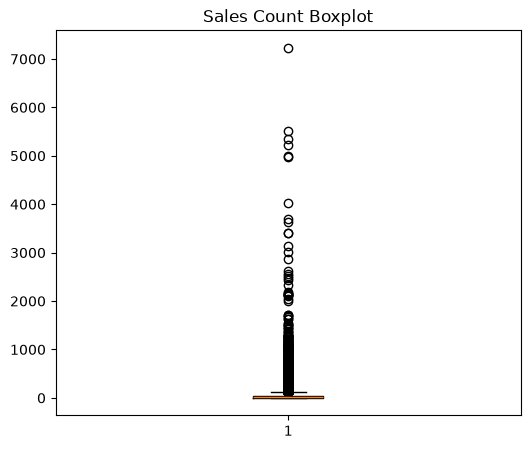

In [446]:
#sales Count Boxplot
plt.figure(figsize=(6,5))
plt.boxplot(df["Sales Count"])
plt.title("Sales Count Boxplot")
plt.show()

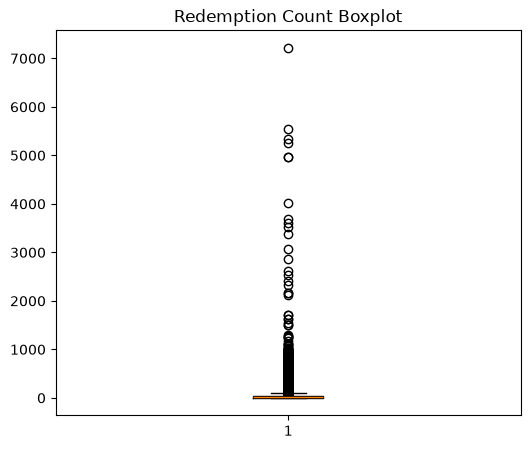

In [447]:
#Redemption Count Boxplot
plt.figure(figsize=(6,5))
plt.boxplot(df["Redemption Count"])
plt.title("Redemption Count Boxplot")
plt.show()

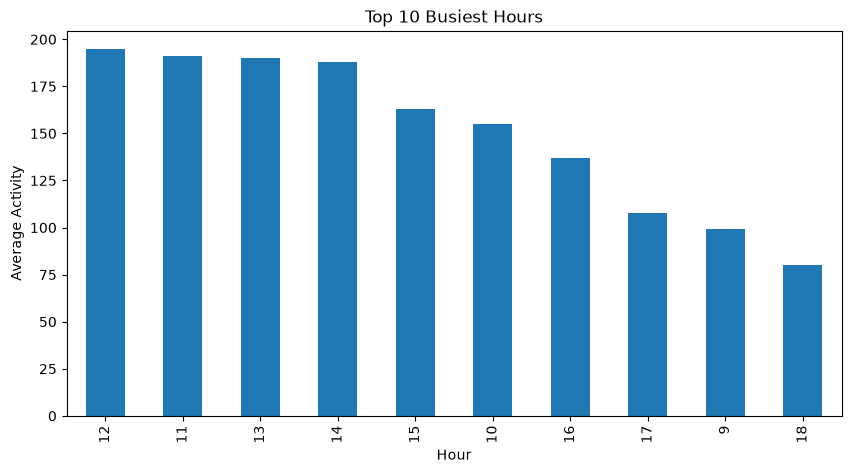

In [448]:
#Top 10 Busiest Hours
top_hours = df.groupby("Hour")["Total Activity Load"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
top_hours.head(10).plot(kind="bar")
plt.title("Top 10 Busiest Hours")
plt.ylabel("Average Activity")
plt.show()

In [449]:
#Capacity utilizatio ratio
capacity_utilization_ratio = df["Total Activity Load"].mean() / df["Total Activity Load"].max()

print("Capacity Utilization Ratio:", round(capacity_utilization_ratio, 3))

Capacity Utilization Ratio: 0.007


In [450]:
#Congestion Pressure Index
congestion_pressure_index = df["Operational Load Index"].mean()

print("Congestion Pressure Index:", round(congestion_pressure_index, 3))

Congestion Pressure Index: 0.007


In [451]:
#Idle Capacity percentage
idle_capacity_percentage = (df["Idle Capacity"].sum() / len(df)) * 100

print("Idle Capacity Percentage:", round(idle_capacity_percentage, 2), "%")

Idle Capacity Percentage: 23.69 %


In [452]:
#Peak strain Duration
peak_threshold = df["Operational Load Index"].quantile(0.90)

peak_duration = (df["Operational Load Index"] >= peak_threshold).sum()

print("Peak Strain Duration:", peak_duration, "intervals")

Peak Strain Duration: 26234 intervals


In [453]:
#Operational Variability Score
operational_variability = df["Total Activity Load"].std()

print("Operational Variability Score:", round(operational_variability, 2))

Operational Variability Score: 200.19


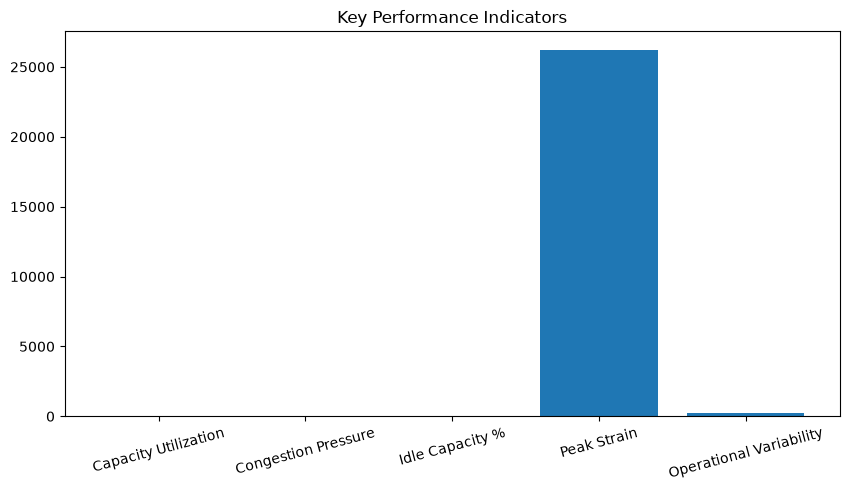

In [454]:
#KPI Visualization
kpi_names = [
    "Capacity Utilization",
    "Congestion Pressure",
    "Idle Capacity %",
    "Peak Strain",
    "Operational Variability"
]

kpi_values = [
    capacity_utilization_ratio,
    congestion_pressure_index,
    idle_capacity_percentage,
    peak_duration,
    operational_variability
]

plt.figure(figsize=(10,5))
plt.bar(kpi_names, kpi_values)
plt.title("Key Performance Indicators")
plt.xticks(rotation=15)
plt.show()

In [455]:
#Set Timestamp as Index
df.set_index("Timestamp", inplace=True)

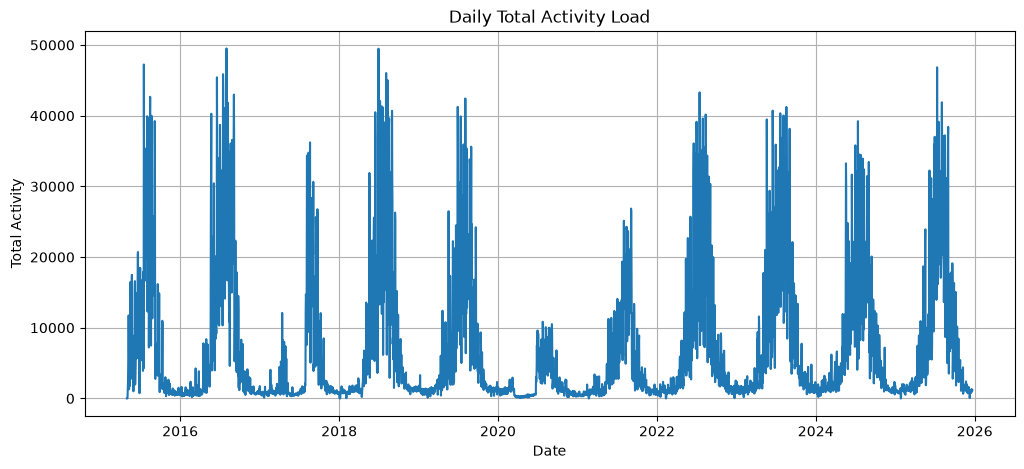

In [456]:
#Daily ACtivity
daily = df["Total Activity Load"].resample("D").sum()

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values)
plt.title("Daily Total Activity Load")
plt.xlabel("Date")
plt.ylabel("Total Activity")
plt.grid(True)
plt.show()

In [ ]:
df["Timestamp"] = pd.to_datetime(df["Timestamp"])
df = df.set_index("Timestamp")

In [ ]:
#Hourly  Activity
hourly = df["Total Activity Load"].resample("h").sum()

plt.figure(figsize=(12,5))
plt.plot(hourly.index, hourly.values)
plt.title("Hourly Total Activity Load")
plt.xlabel("Time")
plt.ylabel("Total Activity")
plt.grid(True)
plt.show()

ValueError: Invalid frequency: H. Failed to parse with error message: ValueError("Invalid frequency: H. Failed to parse with error message: KeyError('H'). Did you mean h?") Did you mean h?

In [ ]:
#Monthly Activity
monthly = df["Total Activity Load"].resample("M").sum()

plt.figure(figsize=(12,5))
plt.plot(monthly.index, monthly.values)
plt.title("Monthly Total Activity Load")
plt.xlabel("Month")
plt.ylabel("Total Activity")
plt.grid(True)
plt.show()

In [ ]:
#Rolling Average (7 days)
rolling = daily.rolling(window=7).mean()

plt.figure(figsize=(12,5))
plt.plot(daily.index, daily.values, label="Daily")
plt.plot(rolling.index, rolling.values, label="7-Day Rolling Average")
plt.legend()
plt.title("Daily Activity with Rolling Average")
plt.show()

In [ ]:
#Heatmap 
pivot = df.pivot_table(
    values="Total Activity Load",
    index="Hour",
    columns="Month_Name",
    aggfunc="mean"
)

plt.figure(figsize=(12,6))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Average Activity")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Heatmap of Activity by Hour and Month")
plt.show()

In [ ]:
df.to_csv("Final_Ferry_Analysis.csv")